In [1]:
from ddgs import DDGS

results = DDGS().images("hotdog", max_results=1)

In [2]:
results[0]["image"]

'http://2.bp.blogspot.com/-OcsfzI7fm1U/U-NzAPt9wvI/AAAAAAAAIbM/0VDBPNn6AbE/s1600/hotdog5.jpeg'

In [3]:
def search_images(query, max_images=10):
    results = DDGS().images(query, max_results=max_images)
    return [result["image"] for result in results]

urls = search_images("hotdog", max_images=5)

In [4]:
urls

['https://www.gaumenfreundin.de/wp-content/uploads/2023/02/Hotdog-Gaumenfreundin.jpg',
 'http://2.bp.blogspot.com/-OcsfzI7fm1U/U-NzAPt9wvI/AAAAAAAAIbM/0VDBPNn6AbE/s1600/hotdog5.jpeg',
 'https://www.gaumenfreundin.de/wp-content/uploads/2023/02/Hotdog-Rezept.jpg',
 'https://potatorolls.com/wp-content/uploads/2020/10/Basic-Hot-Dogs.jpg',
 'https://static.fanpage.it/wp-content/uploads/sites/22/2020/01/hotdog.jpg']

<div><progress max="197434" value="204800"></progress> 103.73% [204800/197434 00:00&lt;00:00]</div>

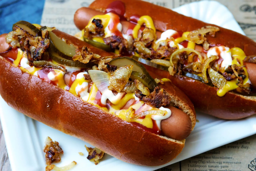

In [5]:
from fastdownload import download_url
dest = "hotdog.jpg"
download_url(urls[0], dest)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256, 256)

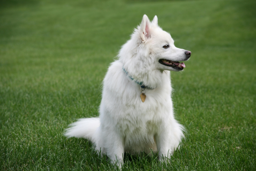

In [6]:
download_url(search_images("dog", max_images=1)[0], "dog.jpg", show_progress=False)
Image.open("dog.jpg").to_thumb(256, 256)

In [7]:
searchs = "hotdog", "dog"
path = Path("hotdog_or_not")

for o in searchs:
    dest = path/o
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(o, max_images=25))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

In [8]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

In [9]:
from fastai.vision.all import *
print(len(get_image_files(path)))

46


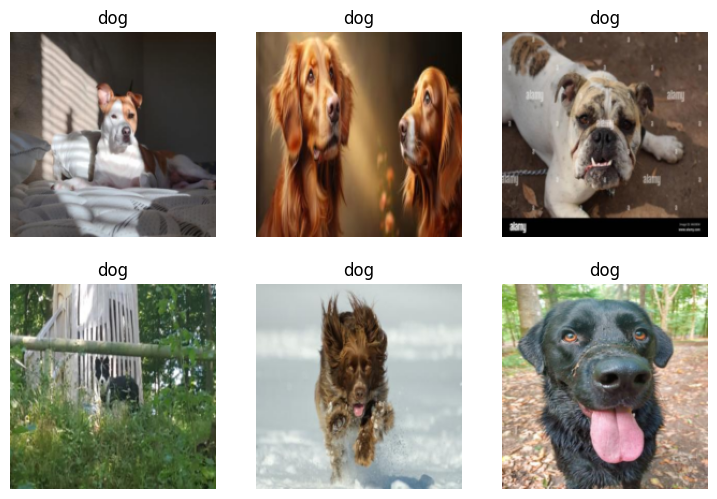

In [10]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method="squish")],
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

In [11]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.266881,3.056054,0.555556,00:01


epoch,train_loss,valid_loss,error_rate,time
0,0.958136,1.808626,0.555556,00:01
1,0.692158,0.364668,0.222222,00:01
2,0.477947,0.067769,0.000000,00:01


In [12]:
is_hotdog,_,probs = learn.predict(PILImage.create('hotdog.jpg'))
print(f"This is a: {is_hotdog}.")
print(f"Probability it's a hotdog: {probs[1]:.4f}")

This is a: hotdog.
Probability it's a hotdog: 0.9967
